# Phase 2 — Notebook 1: Training Window Analysis

**Goal:** Figure out the optimal training window for a fresh model.

Phase 1 used data from 1884–2023 (35K matches). But football from 1884 is irrelevant to 2026.
Modern football, squad quality, and team dynamics have changed massively.

**Question:** What's the right cutoff? 10 years? 20? 30?

We'll test:
- How match patterns change across eras
- EA squad feature coverage by window
- Baseline model performance per window
- Let the data decide

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

DATA_DIR = Path('../../data')
PROCESSED_DIR = DATA_DIR / 'processed'

train_df = pd.read_csv(PROCESSED_DIR / 'train_dc.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test_dc.csv')
team_features = pd.read_csv(PROCESSED_DIR / 'team_features_by_year.csv')

train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])
train_df['year'] = train_df['date'].dt.year
test_df['year'] = test_df['date'].dt.year

print(f'Train: {len(train_df)} matches, {train_df["year"].min()}–{train_df["year"].max()}')
print(f'Test:  {len(test_df)} matches, {test_df["year"].min()}–{test_df["year"].max()}')
print(f'Team features: {team_features["team"].nunique()} teams, years {sorted(team_features["year"].unique())}')

Train: 35304 matches, 1884–2022
Test:  3313 matches, 2022–2026
Team features: 232 teams, years [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


## 1. How has football changed over time?

Let's look at match patterns across decades — goals per game, home advantage, draw rate, etc.

In [2]:
# Match volume and outcome distribution by decade
train_df['decade'] = (train_df['year'] // 10) * 10

decade_stats = train_df.groupby('decade').agg(
    matches=('outcome', 'count'),
    home_win_rate=('outcome', lambda x: (x == 'home_win').mean()),
    draw_rate=('outcome', lambda x: (x == 'draw').mean()),
    away_win_rate=('outcome', lambda x: (x == 'away_win').mean()),
    avg_home_goals=('home_score', 'mean'),
    avg_away_goals=('away_score', 'mean'),
).round(3)

decade_stats['avg_total_goals'] = decade_stats['avg_home_goals'] + decade_stats['avg_away_goals']
decade_stats['home_advantage'] = decade_stats['home_win_rate'] - decade_stats['away_win_rate']

print(decade_stats.to_string())

        matches  home_win_rate  draw_rate  away_win_rate  avg_home_goals  avg_away_goals  avg_total_goals  home_advantage
decade                                                                                                                   
1880         36          0.472      0.111          0.417           3.000           2.583            5.583           0.055
1890         60          0.517      0.150          0.333           3.083           2.100            5.183           0.184
1900         90          0.444      0.211          0.344           2.167           1.511            3.678           0.100
1910        151          0.616      0.146          0.238           2.523           1.265            3.788           0.378
1920        345          0.629      0.142          0.229           2.525           1.281            3.806           0.400
1930        554          0.610      0.119          0.271           2.722           1.762            4.484           0.339
1940        457         

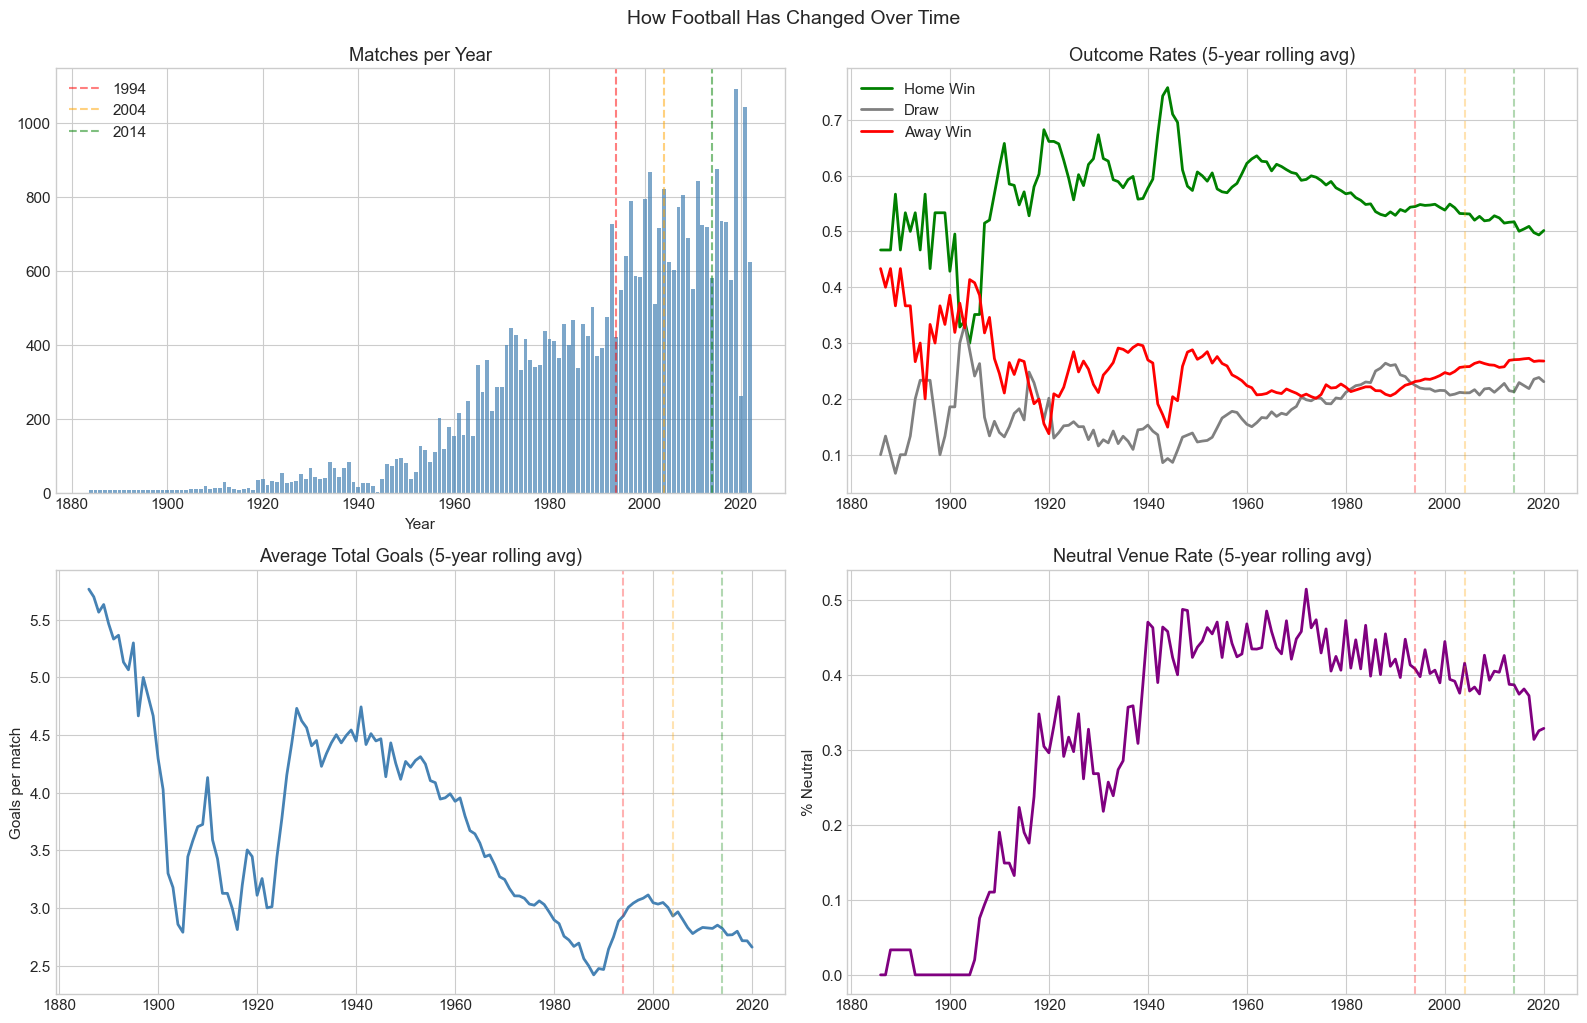

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Match volume
yearly = train_df.groupby('year').size()
axes[0, 0].bar(yearly.index, yearly.values, alpha=0.7, color='steelblue')
axes[0, 0].set_title('Matches per Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].axvline(x=1994, color='red', linestyle='--', alpha=0.5, label='1994')
axes[0, 0].axvline(x=2004, color='orange', linestyle='--', alpha=0.5, label='2004')
axes[0, 0].axvline(x=2014, color='green', linestyle='--', alpha=0.5, label='2014')
axes[0, 0].legend()

# Outcome distribution over time (rolling 5-year)
for outcome, color, label in [('home_win', 'green', 'Home Win'), 
                                ('draw', 'gray', 'Draw'),
                                ('away_win', 'red', 'Away Win')]:
    yearly_rate = train_df.groupby('year')['outcome'].apply(lambda x: (x == outcome).mean())
    axes[0, 1].plot(yearly_rate.rolling(5, center=True).mean(), label=label, color=color, linewidth=2)
axes[0, 1].set_title('Outcome Rates (5-year rolling avg)')
axes[0, 1].legend()
axes[0, 1].axvline(x=1994, color='red', linestyle='--', alpha=0.3)
axes[0, 1].axvline(x=2004, color='orange', linestyle='--', alpha=0.3)
axes[0, 1].axvline(x=2014, color='green', linestyle='--', alpha=0.3)

# Goals per game
yearly_goals = train_df.groupby('year').apply(lambda x: (x['home_score'] + x['away_score']).mean())
axes[1, 0].plot(yearly_goals.rolling(5, center=True).mean(), color='steelblue', linewidth=2)
axes[1, 0].set_title('Average Total Goals (5-year rolling avg)')
axes[1, 0].set_ylabel('Goals per match')
axes[1, 0].axvline(x=1994, color='red', linestyle='--', alpha=0.3)
axes[1, 0].axvline(x=2004, color='orange', linestyle='--', alpha=0.3)
axes[1, 0].axvline(x=2014, color='green', linestyle='--', alpha=0.3)

# Neutral venue percentage
neutral_col = 'neutral.1' if 'neutral.1' in train_df.columns else 'neutral'
yearly_neutral = train_df.groupby('year')[neutral_col].mean()
axes[1, 1].plot(yearly_neutral.rolling(5, center=True).mean(), color='purple', linewidth=2)
axes[1, 1].set_title('Neutral Venue Rate (5-year rolling avg)')
axes[1, 1].set_ylabel('% Neutral')
axes[1, 1].axvline(x=1994, color='red', linestyle='--', alpha=0.3)
axes[1, 1].axvline(x=2004, color='orange', linestyle='--', alpha=0.3)
axes[1, 1].axvline(x=2014, color='green', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.suptitle('How Football Has Changed Over Time', fontsize=14, y=1.02)
plt.savefig('../../notebooks/images/phase2_01_football_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. EA Squad Feature Coverage by Window

EA data starts 2014. FM23 gives proxy ratings for 2014–2025.
What % of matches in each window have squad data?

In [4]:
# Coverage analysis per window
SQUAD_FEATURES = [
    'squad_avg_overall', 'squad_median_overall', 'squad_std_overall',
    'squad_top3_avg', 'squad_bottom5_avg',
    'gk_avg', 'def_avg', 'mid_avg', 'fwd_avg',
    'strongest_unit', 'weakest_unit',
    'squad_total_value', 'squad_avg_value',
    'squad_avg_age', 'squad_avg_potential_gap', 'squad_avg_caps',
    'team_pace', 'team_shooting', 'team_passing',
    'team_dribbling', 'team_defending', 'team_physic',
]

# Build coverage lookup
covered_by_year = {}
for yr in sorted(team_features['year'].unique()):
    covered_by_year[yr] = set(team_features[team_features['year'] == yr]['team'])

def has_squad(row, covered_by_year):
    yr = row['year']
    avail = [y for y in covered_by_year if y <= yr]
    if not avail:
        return False
    best_yr = max(avail)
    teams = covered_by_year[best_yr]
    return row['home_team'] in teams and row['away_team'] in teams

train_df['has_squad'] = train_df.apply(lambda r: has_squad(r, covered_by_year), axis=1)

windows = {
    '2014+ (10yr)': 2014,
    '2004+ (20yr)': 2004,
    '1994+ (30yr)': 1994,
    '1984+ (40yr)': 1984,
    'All (1884+)': 1884,
}

print(f'{"Window":20s} | {"Matches":>8s} | {"Squad Coverage":>15s} | {"Unique Teams":>12s}')
print('-' * 65)
for name, start_yr in windows.items():
    subset = train_df[train_df['year'] >= start_yr]
    n = len(subset)
    sq = subset['has_squad'].sum()
    teams = set(subset['home_team'].unique()) | set(subset['away_team'].unique())
    print(f'{name:20s} | {n:>8,d} | {sq:>6,d} ({sq/n*100:5.1f}%) | {len(teams):>12,d}')

Window               |  Matches |  Squad Coverage | Unique Teams
-----------------------------------------------------------------
2014+ (10yr)         |    6,516 |  6,072 ( 93.2%) |          282
2004+ (20yr)         |   13,667 |  6,072 ( 44.4%) |          297
1994+ (30yr)         |   20,125 |  6,072 ( 30.2%) |          303
1984+ (40yr)         |   24,671 |  6,072 ( 24.6%) |          306
All (1884+)          |   35,304 |  6,072 ( 17.2%) |          312


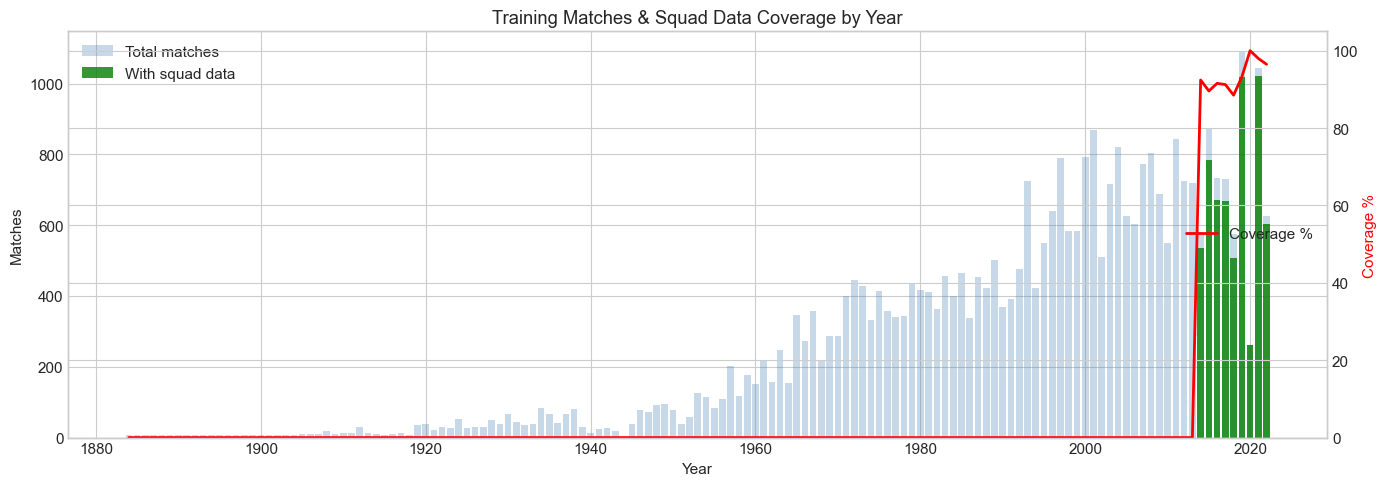

In [5]:
# Visualize coverage by year
yearly_coverage = train_df.groupby('year').agg(
    total=('has_squad', 'count'),
    covered=('has_squad', 'sum')
)
yearly_coverage['pct'] = yearly_coverage['covered'] / yearly_coverage['total'] * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(yearly_coverage.index, yearly_coverage['total'], alpha=0.3, color='steelblue', label='Total matches')
ax.bar(yearly_coverage.index, yearly_coverage['covered'], alpha=0.8, color='green', label='With squad data')
ax.set_title('Training Matches & Squad Data Coverage by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Matches')
ax.legend()

ax2 = ax.twinx()
ax2.plot(yearly_coverage.index, yearly_coverage['pct'], color='red', linewidth=2, label='Coverage %')
ax2.set_ylabel('Coverage %', color='red')
ax2.set_ylim(0, 105)
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('../../notebooks/images/phase2_01_squad_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Tournament Type Distribution by Era

Are we losing important tournament matches by cutting old data?

In [6]:
# Tournament type distribution per window
if 'tournament' in train_df.columns:
    for name, start_yr in windows.items():
        subset = train_df[train_df['year'] >= start_yr]
        print(f'\n=== {name} ({len(subset):,d} matches) ===')
        # Group by tournament importance
        imp_dist = subset['tournament_importance'].value_counts().sort_index()
        for imp, cnt in imp_dist.items():
            label = {1: 'Friendly', 2: 'Qualifier', 3: 'Continental', 4: 'World Cup'}.get(imp, f'Level {imp}')
            print(f'  {label:15s}: {cnt:>5d} ({cnt/len(subset)*100:5.1f}%)')
else:
    print('No tournament column found')


=== 2014+ (10yr) (6,516 matches) ===
  Friendly       :   860 ( 13.2%)
  Qualifier      :  3440 ( 52.8%)
  Continental    :  2035 ( 31.2%)
  World Cup      :   181 (  2.8%)

=== 2004+ (20yr) (13,667 matches) ===
  Friendly       :  2085 ( 15.3%)
  Qualifier      :  7398 ( 54.1%)
  Continental    :  3757 ( 27.5%)
  World Cup      :   427 (  3.1%)

=== 1994+ (30yr) (20,125 matches) ===
  Friendly       :  3617 ( 18.0%)
  Qualifier      : 10910 ( 54.2%)
  Continental    :  4920 ( 24.4%)
  World Cup      :   678 (  3.4%)

=== 1984+ (40yr) (24,671 matches) ===
  Friendly       :  5039 ( 20.4%)
  Qualifier      : 13248 ( 53.7%)
  Continental    :  5558 ( 22.5%)
  World Cup      :   826 (  3.3%)

=== All (1884+) (35,304 matches) ===
  Friendly       : 10310 ( 29.2%)
  Qualifier      : 16964 ( 48.1%)
  Continental    :  6699 ( 19.0%)
  World Cup      :  1331 (  3.8%)


## 4. Training Window Experiment

Train simple models on different windows, test on the same test set.

**Features used:** Only form + H2H + tournament/neutral + EA squad features. **NO ELO, NO DC.**

This is a clean test — how well can we predict with modern, unbiased features?

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import log_loss, accuracy_score
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb

# === DEFINE CLEAN FEATURE SETS (NO ELO, NO DC) ===

# Form features (derived from recent match results — less biased than ELO)
FORM_FEATURES = [
    'home_win_rate_5', 'home_avg_scored_5', 'home_avg_conceded_5',
    'home_pts_per_match_5', 'home_matches_played_5',
    'home_win_rate_10', 'home_avg_scored_10', 'home_avg_conceded_10',
    'home_pts_per_match_10', 'home_matches_played_10',
    'away_win_rate_5', 'away_avg_scored_5', 'away_avg_conceded_5',
    'away_pts_per_match_5', 'away_matches_played_5',
    'away_win_rate_10', 'away_avg_scored_10', 'away_avg_conceded_10',
    'away_pts_per_match_10', 'away_matches_played_10',
]

# Engineered form features
FORM_ENGINEERED = [
    'home_form_momentum', 'away_form_momentum',
    'home_goal_diff_form', 'away_goal_diff_form', 'net_goal_diff',
]

# H2H features
H2H_FEATURES = [
    'h2h_home_win_rate', 'h2h_home_avg_scored', 'h2h_home_avg_conceded',
    'h2h_total_meetings', 'h2h_recent_win_rate', 'h2h_confidence',
]

# Context features
CONTEXT_FEATURES = [
    'neutral.1', 'tournament_importance',
    'home_conf_UEFA', 'home_conf_CAF', 'home_conf_AFC',
    'home_conf_CONCACAF', 'home_conf_CONMEBOL', 'home_conf_OFC', 'home_conf_UNKNOWN',
    'away_conf_UEFA', 'away_conf_CAF', 'away_conf_AFC',
    'away_conf_CONCACAF', 'away_conf_CONMEBOL', 'away_conf_OFC', 'away_conf_UNKNOWN',
    'same_confederation',
]

# EA squad diff features (the clean, independent signal)
DIFF_FEATURES = [
    'squad_avg_overall_diff', 'squad_top3_avg_diff', 'squad_value_diff',
    'def_avg_diff', 'mid_avg_diff', 'fwd_avg_diff',
    'team_shooting_diff', 'team_passing_diff', 'team_defending_diff',
]

# Feature sets to test
CLEAN_NO_EA = FORM_FEATURES + FORM_ENGINEERED + H2H_FEATURES + CONTEXT_FEATURES
CLEAN_WITH_EA = CLEAN_NO_EA + DIFF_FEATURES

print(f'Clean (no EA): {len(CLEAN_NO_EA)} features')
print(f'Clean (with EA): {len(CLEAN_WITH_EA)} features')

Clean (no EA): 48 features
Clean (with EA): 57 features


In [8]:
# Join squad features to train and test
def join_squad(df):
    df = df.copy()
    avail = sorted(team_features['year'].unique())
    def get_yr(y):
        c = [x for x in avail if x <= y]
        return max(c) if c else None
    df['fifa_year'] = df['year'].apply(get_yr)
    
    htf = team_features.rename(columns={f: f'home_{f}' for f in SQUAD_FEATURES})
    htf = htf.rename(columns={'team': 'home_team', 'year': 'fifa_year'})
    atf = team_features.rename(columns={f: f'away_{f}' for f in SQUAD_FEATURES})
    atf = atf.rename(columns={'team': 'away_team', 'year': 'fifa_year'})
    
    home_cols = ['home_team', 'fifa_year'] + [f'home_{f}' for f in SQUAD_FEATURES]
    away_cols = ['away_team', 'fifa_year'] + [f'away_{f}' for f in SQUAD_FEATURES]
    
    df = df.merge(htf[home_cols], on=['home_team', 'fifa_year'], how='left')
    df = df.merge(atf[away_cols], on=['away_team', 'fifa_year'], how='left')
    
    df['squad_avg_overall_diff'] = df['home_squad_avg_overall'] - df['away_squad_avg_overall']
    df['squad_top3_avg_diff'] = df['home_squad_top3_avg'] - df['away_squad_top3_avg']
    df['squad_value_diff'] = df['home_squad_total_value'] - df['away_squad_total_value']
    df['def_avg_diff'] = df['home_def_avg'] - df['away_def_avg']
    df['mid_avg_diff'] = df['home_mid_avg'] - df['away_mid_avg']
    df['fwd_avg_diff'] = df['home_fwd_avg'] - df['away_fwd_avg']
    df['team_shooting_diff'] = df['home_team_shooting'] - df['away_team_shooting']
    df['team_passing_diff'] = df['home_team_passing'] - df['away_team_passing']
    df['team_defending_diff'] = df['home_team_defending'] - df['away_team_defending']
    return df

train_aug = join_squad(train_df)
test_aug = join_squad(test_df)

le = LabelEncoder()
y_test = le.fit_transform(test_aug['outcome'].values)
print(f'Classes: {le.classes_}')
print(f'Test set: {len(test_aug)} matches')

Classes: ['away_win' 'draw' 'home_win']
Test set: 3313 matches


In [9]:
# === WINDOW EXPERIMENT ===
XGB_P = dict(n_estimators=200, max_depth=5, learning_rate=0.05,
             subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0)

results = []

test_windows = {
    '2018+ (6yr)': 2018,
    '2014+ (10yr)': 2014,
    '2010+ (14yr)': 2010,
    '2004+ (20yr)': 2004,
    '1994+ (30yr)': 1994,
    '1984+ (40yr)': 1984,
    'All': 1884,
}

for window_name, start_yr in test_windows.items():
    train_w = train_aug[train_aug['year'] >= start_yr].copy()
    y_train_w = le.transform(train_w['outcome'].values)
    n_train = len(train_w)
    
    # Squad coverage
    sq_cov = train_w['has_squad'].mean() * 100
    
    for feat_name, feat_cols in [('Clean (no EA)', CLEAN_NO_EA), ('Clean + EA diff', CLEAN_WITH_EA)]:
        X_tr = train_w[feat_cols].values
        X_te = test_aug[feat_cols].values
        
        # XGBoost with NaN native handling (no scaler needed, no fillna)
        model = CalibratedClassifierCV(
            xgb.XGBClassifier(**XGB_P, eval_metric='mlogloss', random_state=42, verbosity=0),
            method='isotonic', cv=5)
        model.fit(X_tr, y_train_w)
        p = model.predict_proba(X_te)
        
        ll = log_loss(y_test, p)
        acc = accuracy_score(y_test, np.argmax(p, axis=1))
        results.append((window_name, feat_name, n_train, sq_cov, ll, acc))
        print(f'  {window_name:15s} | {feat_name:18s} | n={n_train:>6,d} | sq={sq_cov:5.1f}% | ll={ll:.4f} | acc={acc:.4f}')

  2018+ (6yr)     | Clean (no EA)      | n= 3,597 | sq= 94.9% | ll=0.9025 | acc=0.5883
  2018+ (6yr)     | Clean + EA diff    | n= 3,597 | sq= 94.9% | ll=0.8805 | acc=0.6007
  2014+ (10yr)    | Clean (no EA)      | n= 6,516 | sq= 93.2% | ll=0.8993 | acc=0.5982
  2014+ (10yr)    | Clean + EA diff    | n= 6,516 | sq= 93.2% | ll=0.8620 | acc=0.6139
  2010+ (14yr)    | Clean (no EA)      | n= 9,353 | sq= 64.9% | ll=0.8789 | acc=0.5976
  2010+ (14yr)    | Clean + EA diff    | n= 9,353 | sq= 64.9% | ll=0.8534 | acc=0.6133
  2004+ (20yr)    | Clean (no EA)      | n=13,667 | sq= 44.4% | ll=0.8863 | acc=0.5967
  2004+ (20yr)    | Clean + EA diff    | n=13,667 | sq= 44.4% | ll=0.8515 | acc=0.6155
  1994+ (30yr)    | Clean (no EA)      | n=20,125 | sq= 30.2% | ll=0.8754 | acc=0.5964
  1994+ (30yr)    | Clean + EA diff    | n=20,125 | sq= 30.2% | ll=0.8504 | acc=0.6130
  1984+ (40yr)    | Clean (no EA)      | n=24,671 | sq= 24.6% | ll=0.8738 | acc=0.6010
  1984+ (40yr)    | Clean + EA diff    | n=

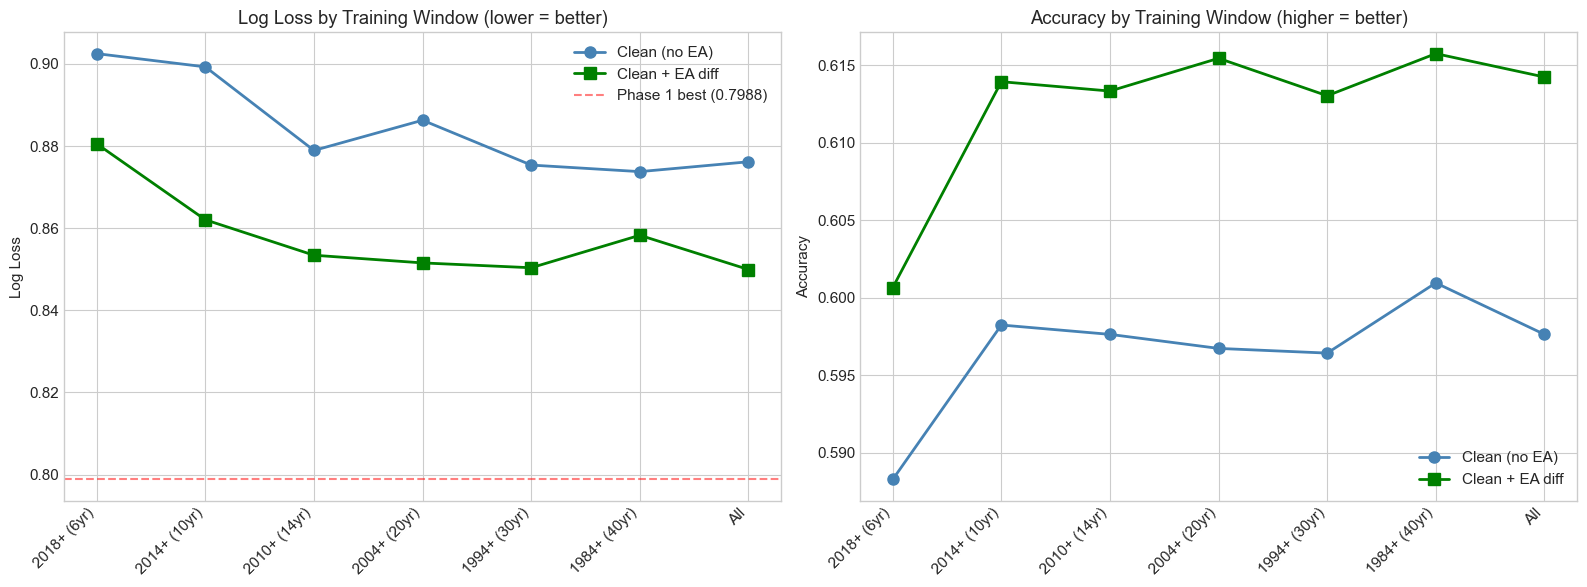

In [10]:
# Visualize results
res_df = pd.DataFrame(results, columns=['window', 'features', 'n_train', 'sq_coverage', 'log_loss', 'accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for feat_name, color, marker in [('Clean (no EA)', 'steelblue', 'o'), ('Clean + EA diff', 'green', 's')]:
    subset = res_df[res_df['features'] == feat_name]
    axes[0].plot(range(len(subset)), subset['log_loss'].values, 
                 marker=marker, color=color, linewidth=2, markersize=8, label=feat_name)
    axes[1].plot(range(len(subset)), subset['accuracy'].values,
                 marker=marker, color=color, linewidth=2, markersize=8, label=feat_name)

window_labels = list(test_windows.keys())
for ax in axes:
    ax.set_xticks(range(len(window_labels)))
    ax.set_xticklabels(window_labels, rotation=45, ha='right')
    ax.legend()

axes[0].set_title('Log Loss by Training Window (lower = better)')
axes[0].set_ylabel('Log Loss')
axes[0].axhline(y=0.7988, color='red', linestyle='--', alpha=0.5, label='Phase 1 best (0.7988)')
axes[0].legend()

axes[1].set_title('Accuracy by Training Window (higher = better)')
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.savefig('../../notebooks/images/phase2_01_window_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Results table
print('\n' + '=' * 90)
print('TRAINING WINDOW EXPERIMENT — RESULTS')
print('=' * 90)
print(f'{"Window":15s} | {"Features":18s} | {"Train":>7s} | {"Sq Cov":>7s} | {"Log Loss":>9s} | {"Acc":>7s}')
print('-' * 90)
for _, row in res_df.sort_values('log_loss').iterrows():
    print(f'{row["window"]:15s} | {row["features"]:18s} | {row["n_train"]:>7,d} | {row["sq_coverage"]:>6.1f}% | {row["log_loss"]:>9.4f} | {row["accuracy"]:>7.4f}')

print(f'\nPhase 1 reference: 0.7988 (with ELO + DC)')


TRAINING WINDOW EXPERIMENT — RESULTS
Window          | Features           |   Train |  Sq Cov |  Log Loss |     Acc
------------------------------------------------------------------------------------------
All             | Clean + EA diff    |  35,304 |   17.2% |    0.8499 |  0.6142
1994+ (30yr)    | Clean + EA diff    |  20,125 |   30.2% |    0.8504 |  0.6130
2004+ (20yr)    | Clean + EA diff    |  13,667 |   44.4% |    0.8515 |  0.6155
2010+ (14yr)    | Clean + EA diff    |   9,353 |   64.9% |    0.8534 |  0.6133
1984+ (40yr)    | Clean + EA diff    |  24,671 |   24.6% |    0.8583 |  0.6158
2014+ (10yr)    | Clean + EA diff    |   6,516 |   93.2% |    0.8620 |  0.6139
1984+ (40yr)    | Clean (no EA)      |  24,671 |   24.6% |    0.8738 |  0.6010
1994+ (30yr)    | Clean (no EA)      |  20,125 |   30.2% |    0.8754 |  0.5964
All             | Clean (no EA)      |  35,304 |   17.2% |    0.8762 |  0.5976
2010+ (14yr)    | Clean (no EA)      |   9,353 |   64.9% |    0.8789 |  0.5976
20

In [12]:
# === EA FEATURE VALUE: how much does EA improve each window? ===
print('\n' + '=' * 70)
print('EA FEATURE VALUE — improvement per window')
print('=' * 70)

for window_name in test_windows.keys():
    no_ea = res_df[(res_df['window'] == window_name) & (res_df['features'] == 'Clean (no EA)')]['log_loss'].values[0]
    with_ea = res_df[(res_df['window'] == window_name) & (res_df['features'] == 'Clean + EA diff')]['log_loss'].values[0]
    delta = with_ea - no_ea
    sq_cov = res_df[(res_df['window'] == window_name) & (res_df['features'] == 'Clean + EA diff')]['sq_coverage'].values[0]
    arrow = '<<<' if delta < -0.005 else '<' if delta < 0 else ''
    print(f'  {window_name:15s}  no_ea={no_ea:.4f}  +ea={with_ea:.4f}  delta={delta:+.4f}  sq_cov={sq_cov:.0f}%  {arrow}')


EA FEATURE VALUE — improvement per window
  2018+ (6yr)      no_ea=0.9025  +ea=0.8805  delta=-0.0220  sq_cov=95%  <<<
  2014+ (10yr)     no_ea=0.8993  +ea=0.8620  delta=-0.0372  sq_cov=93%  <<<
  2010+ (14yr)     no_ea=0.8789  +ea=0.8534  delta=-0.0255  sq_cov=65%  <<<
  2004+ (20yr)     no_ea=0.8863  +ea=0.8515  delta=-0.0348  sq_cov=44%  <<<
  1994+ (30yr)     no_ea=0.8754  +ea=0.8504  delta=-0.0250  sq_cov=30%  <<<
  1984+ (40yr)     no_ea=0.8738  +ea=0.8583  delta=-0.0155  sq_cov=25%  <<<
  All              no_ea=0.8762  +ea=0.8499  delta=-0.0262  sq_cov=17%  <<<


## 5. Conclusion

Based on the results above:

1. **Optimal training window:** Which window gives the best log loss with clean features?
2. **EA feature value:** In which window does EA data help the most?
3. **Data volume vs relevance:** Where's the sweet spot?

**Next:** Notebook 02 — EDA on the chosen window with the clean feature set.

In [13]:
# Summary
best = res_df.loc[res_df['log_loss'].idxmin()]
print(f'\nBest result:')
print(f'  Window: {best["window"]}')
print(f'  Features: {best["features"]}')
print(f'  Log Loss: {best["log_loss"]:.4f}')
print(f'  Accuracy: {best["accuracy"]:.4f}')
print(f'  Train size: {best["n_train"]:,.0f}')
print(f'  Squad coverage: {best["sq_coverage"]:.1f}%')
print(f'\n  vs Phase 1 (with ELO+DC): 0.7988')
print(f'  Gap: {best["log_loss"] - 0.7988:+.4f}')


Best result:
  Window: All
  Features: Clean + EA diff
  Log Loss: 0.8499
  Accuracy: 0.6142
  Train size: 35,304
  Squad coverage: 17.2%

  vs Phase 1 (with ELO+DC): 0.7988
  Gap: +0.0511
